In [4]:
#Import thư viện cho cả 3 thuật toán
#-------Cho KMeans--------
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.cluster import KMeans,DBSCAN
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from yellowbrick.cluster import KElbowVisualizer, SilhouetteVisualizer
import numpy as np
import seaborn as sns
from sklearn.preprocessing import StandardScaler
#from sklearn_extra.cluster import KMedoids
from sklearn.neighbors import NearestNeighbors
import joblib


In [5]:
#======Các tham số chung=========
Dataset_path="/content/drive/MyDrive/KhaiPhaDuLieu/dataset_final.csv"
save_path = "/content/drive/MyDrive/KhaiPhaDuLieu/AnhKetQuaClustering"
#Load dataset
df_preprocessed = pd.read_csv(Dataset_path)
X = df_preprocessed.values

***Ý nghĩa các chỉ số đánh giá chung***
1. Silhouette Score: Một điểm dữ liệu có thực sự thuộc về cụm đó hay không
2. Calinski Harabasz: Các cụm có cách xa nhau hay không. Mỗi cụm có đủ chặt hay không
3. Devies-Bouldin Index: Mỗi cụm giống cụm gần nhất đến mức nào

**K-MEANS**

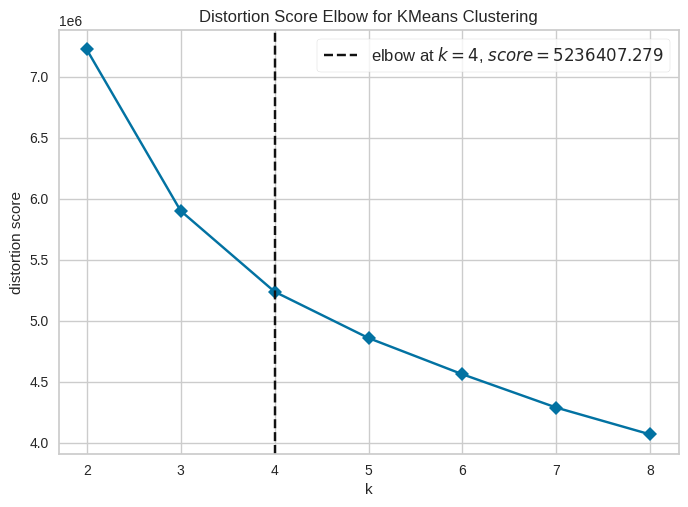

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [6]:
# Tìm K tối ưu bằng phương pháp Elbow
model = KMeans(random_state=42, n_init=10)
#Vẽ biểu đồ để chọn k tối ưu nhất
visualizer = KElbowVisualizer(model, k=(2, 9), timings=False)
visualizer.fit(X)#tìm K
visualizer.show()


In [7]:
#Gom cụm với k tốt nhất
BEST_K = 3
kmeans = KMeans(n_clusters=BEST_K, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X)

# Lưu kết quả gom cụm lại vào dữ liệu gốc
df_final = df_preprocessed.copy()
df_final["Cluster"] = cluster_labels
print(f"-> Đã gom cụm thành công với K = {BEST_K}. Số lượng mẫu mỗi cụm:\n")
print(df_final["Cluster"].value_counts().sort_index())

-> Đã gom cụm thành công với K = 3. Số lượng mẫu mỗi cụm:

Cluster
0    222122
1     35596
2    242281
Name: count, dtype: int64


In [8]:
#Lấy ngẫu nhiên 50000 mẫu để đánh giá
df_sample_metrics = df_final.sample(n=50000, random_state=42)
X_sample_metrics = df_sample_metrics.drop(columns=['Cluster']).values
labels_sample_metrics = df_sample_metrics['Cluster'].values

In [9]:
#Tính chỉ số Silhouette Score tổng thể ->Càng gần 1 càng tốt
score = silhouette_score(X, cluster_labels,sample_size=50000, random_state=42)
print(f"1. Chỉ số Silhouette Score tổng thể: {score:.4f}")

#Tính chỉ số Calinski–Harabasz Index ->Càng lớn càng tốt
ch_index = calinski_harabasz_score(X_sample_metrics, labels_sample_metrics)
print(f"2. Chỉ số Calinski–Harabasz Index: {ch_index:.2f}")

#Tính chỉ số Davies–Bouldin Index ->Càng nhỏ càng tốt
db_index = davies_bouldin_score(X_sample_metrics, labels_sample_metrics)
print(f"3. Chỉ số Davies–Bouldin Index: {db_index:.4f}")

1. Chỉ số Silhouette Score tổng thể: 0.2911
2. Chỉ số Calinski–Harabasz Index: 22545.24
3. Chỉ số Davies–Bouldin Index: 1.1688


Đã lưu ảnh biểu đồ thành công!


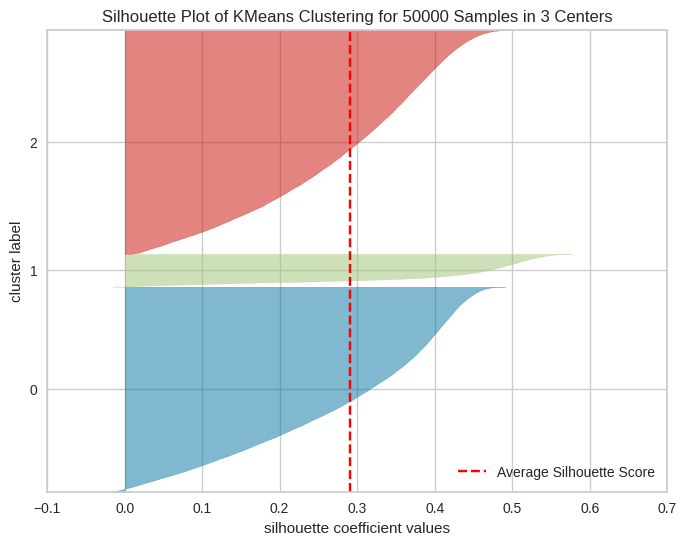

<Axes: title={'center': 'Silhouette Plot of KMeans Clustering for 50000 Samples in 3 Centers'}, xlabel='silhouette coefficient values', ylabel='cluster label'>

In [10]:

#Vẽ biểu đồ Silhouette chi tiết cho từng cụm
plt.figure(figsize=(8, 6))
sil_visualizer = SilhouetteVisualizer(kmeans, colors='yellowbrick')
sil_visualizer.fit(X_sample_metrics) # Tính toán và vẽ biểu đồ
plt.savefig(f"{save_path}/{BEST_K}_Means_Silhouette", dpi=300, bbox_inches='tight')
print("Đã lưu ảnh biểu đồ thành công!")
sil_visualizer.show()# Hiển thị biểu đồ mật độ cụm



In [11]:
#Giá trị trung bình (Đặc trưng) của từng cụm để phân tích hành vi
cluster_summary = df_final.groupby("Cluster").mean()
print("\nGiá trị đặc trưng trung bình của từng cụm:")
print(cluster_summary.round(2))


Giá trị đặc trưng trung bình của từng cụm:
          PC1   PC2   PC3   PC4  PC5   PC6   PC7   PC8   PC9
Cluster                                                     
0        3.16 -0.22  0.11  0.29  0.0 -0.00 -0.00 -0.04  0.06
1       -6.77 -2.39  0.69  2.61  0.0  0.01 -0.01 -0.47 -0.35
2       -1.91  0.55 -0.20 -0.65 -0.0 -0.00  0.00  0.11 -0.01


In [12]:
joblib.dump(kmeans, "/content/drive/MyDrive/KhaiPhaDuLieu/kmeans_model.pkl")
print("Đã lưu model KMeans thành công!")

Đã lưu model KMeans thành công!


**K-MEDIODS**???

In [ ]:
df_final = df_preprocessed.copy()

# TÌM K TỐI ƯU (EVALUATION & OPTIMAL K)
silhouette_scores = []
K_range = range(2, 6) # Thử K từ 2 đến 5 cụm

for k in K_range:
    kmedoids = KMedoids(n_clusters=k, random_state=42, metric='euclidean')
    labels = kmedoids.fit_predict(X)
    score = silhouette_score(X, labels)
    silhouette_scores.append(score)
    print(f" - Nếu chia {k} cụm: Silhouette Score = {score:.4f}")

# Chọn K có điểm số cao nhất
best_k = K_range[np.argmax(silhouette_scores)]
print(f"CHỌN K TỐI ƯU = {best_k}")

# 3. THỰC THI K-MEDOIDS (IMPLEMENTATION)
print(f"\n3. Đang huấn luyện mô hình K-Medoids với K={best_k}...")
kmedoids_final = KMedoids(n_clusters=best_k, random_state=42)
df_final['Cluster'] = kmedoids_final.fit_predict(X)



In [ ]:
# TRỰC QUAN HÓA (VISUALIZATION)
# Giảm chiều dữ liệu xuống 2D để vẽ biểu đồ
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)
df_final['PCA1'] = X_pca[:, 0]
df_final['PCA2'] = X_pca[:, 1]
# Lấy tọa độ của các tâm cụm (Medoids)
medoids_indices = kmedoids_final.medoid_indices_
medoids_pca = X_pca[medoids_indices]
# Vẽ hình
plt.figure(figsize=(10, 7))
sns.scatterplot(x='PCA1', y='PCA2', hue='Cluster', data=df_final, palette='Set2', alpha=0.7)
# Đánh dấu các điểm Medoids
plt.scatter(medoids_pca[:, 0], medoids_pca[:, 1], marker='*', s=400, c='red', edgecolor='black', label='Medoid (Tâm cụm)')
plt.title(f'Biểu đồ phân cụm người dùng mạng xã hội bằng K-Medoids (K={best_k})', fontsize=14)
plt.legend()
plt.show()

In [ ]:
#Tính chỉ số Silhouette Score tổng thể ->Càng gần 1 càng tốt
score = silhouette_score(X, cluster_labels,sample_size=50000, random_state=42)
print(f"1. Chỉ số Silhouette Score tổng thể: {score:.4f}")

#Tính chỉ số Calinski–Harabasz Index ->Càng lớn càng tốt
ch_index = calinski_harabasz_score(X_sample_metrics, labels_sample_metrics)
print(f"2. Chỉ số Calinski–Harabasz Index: {ch_index:.2f}")

#Tính chỉ số Davies–Bouldin Index ->Càng nhỏ càng tốt
db_index = davies_bouldin_score(X_sample_metrics, labels_sample_metrics)
print(f"3. Chỉ số Davies–Bouldin Index: {db_index:.4f}")

In [ ]:
#Vẽ biểu đồ Silhouette chi tiết cho từng cụm
plt.figure(figsize=(8, 6))
sil_visualizer = SilhouetteVisualizer(kmeans, colors='yellowbrick')
sil_visualizer.fit(X_sample_metrics) # Tính toán và vẽ biểu đồ
plt.savefig(f"{save_path}/{best_k}_Mediols_Silhouette", dpi=300, bbox_inches='tight')
print("Đã lưu ảnh biểu đồ thành công!")
sil_visualizer.show()# Hiển thị biểu đồ mật độ cụm

In [ ]:
#Giá trị trung bình (Đặc trưng) của từng cụm để phân tích hành vi
cluster_summary = df_final.groupby("Cluster").mean()
print("\Giá trị đặc trưng trung bình của từng cụm:")
print(cluster_summary.round(2))

**DBSCAN**